# LSTM Reimplementation

This notebook reproduces the LSTM-based fake news detection model from:

> Liu, S. (2023). *Social Media Fake Information Identification Method Based on LSTM*. GEFHR 2023, Vol. 21, pp. 703–709.

All model parameters follow the original paper exactly (Table 2). The goal is to verify that the reported 99% accuracy and 100% AUC are reproducible, and to understand what drives those numbers given the dataset bias identified in `00_eda.ipynb`.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Keras is now integrated into TensorFlow (tf.keras = Keras)
# keras.preprocessing.text was removed in Keras 3 — use tensorflow.keras instead
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

os.makedirs('../results', exist_ok=True)
print('TensorFlow:', tf.__version__)
print('Keras:', tf.keras.__version__)

/Users/sl1425/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TensorFlow: 2.16.2
Keras: 3.10.0


## 2. Load Data

In [2]:
fake = pd.read_csv('../data/raw/Fake.csv')
true = pd.read_csv('../data/raw/True.csv')

fake['label'] = 0
true['label'] = 1

df = pd.concat([fake, true]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Total: {len(df):,} rows')
print(df['label'].value_counts())

Total: 44,898 rows
label
0    23481
1    21417
Name: count, dtype: int64


原论文使用 `title + text` 作为输入文本，`subject` 和 `date` 列并未显式排除，因此模型可能接触到了泄露特征（见 `00_eda.ipynb`）。为忠实复现原论文，这里沿用相同设置——使用 `text` 列作为输入。

The original paper uses the article text as input without explicitly removing `subject` or `date`. To faithfully reproduce the paper's results, we follow the same setup here and use the `text` column as input.

## 3. Text Preprocessing

按照原论文的流程，文本预处理分三步：划分训练测试集 → Tokenizer 建立词表 → 将文本转换为数字序列并统一长度（padding）。

Following the original paper, preprocessing has three steps: train/test split → Tokenizer vocabulary construction → convert text to padded integer sequences.

In [3]:
# Train/test split — 80/20, matching original paper
X = df['text'].fillna('')
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')

Train: 35,918  |  Test: 8,980


In [4]:
# Tokenizer — num_words=5000 matches original paper
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

vocab_size = len(tokenizer.word_index)
print(f'Full vocabulary size: {vocab_size:,}')
print(f'Using top 5,000 words (as per original paper)')

Full vocabulary size: 125,515
Using top 5,000 words (as per original paper)


In [5]:
# Convert text to sequences and pad to length 200 — matches original paper
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=200)
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=200)

print(f'X_train shape: {X_train_seq.shape}')
print(f'X_test shape:  {X_test_seq.shape}')

X_train shape: (35918, 200)
X_test shape:  (8980, 200)


预处理完成后，每篇文章被表示为一个长度为 200 的整数数组。数组里每个数字是词在词表中的编号，不足 200 词的文章用 0 补齐（zero-padding），超过 200 词的文章被截断。这个格式就是 LSTM 模型接受的输入形状：`(样本数, 200)`。

After preprocessing, each article is represented as an integer array of length 200. Each integer is the index of a word in the vocabulary. Articles shorter than 200 words are zero-padded; longer ones are truncated. The resulting shape `(n_samples, 200)` is the direct input to the LSTM model.

## 4. Build LSTM Model

按照原论文 Table 2 的参数逐层搭建模型，暂不训练。

Model architecture follows Table 2 of the original paper exactly. No training yet — just define and inspect the structure.

In [6]:
model = Sequential([
    # 词嵌入层：把每个词的编号映射成 100 维向量
    # Embedding: maps each word index to a 100-dimensional vector
    Embedding(input_dim=5000, output_dim=100, input_length=200),

    # LSTM 层：读取词序列，学习上下文关系；dropout 防止过拟合
    # LSTM: learns sequential patterns; dropout reduces overfitting
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),

    # 全连接层：提取更高层的特征
    # Dense: extracts higher-level features
    Dense(64, activation='relu'),

    # Dropout：训练时随机关掉 50% 神经元，防止过拟合
    # Dropout: randomly disables 50% of neurons during training
    Dropout(0.5),

    # 输出层：输出 0~1 的概率，>0.5 为真新闻
    # Output: probability score — >0.5 classified as real news
    Dense(1, activation='sigmoid')
])

# 编译模型：损失函数、优化器、评估指标
# Compile: loss function, optimiser, evaluation metric
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/Users/sl1425/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

模型共五层，参数量主要集中在 Embedding 层（5000×100 = 500,000 个参数）和 LSTM 层。最终输出一个 0~1 的概率值，代表这篇文章是真新闻的可能性。

The model has five layers. Most parameters live in the Embedding layer (5,000 × 100 = 500,000) and the LSTM layer. The final output is a single probability score representing the likelihood that the article is real news.

## 5. Train Model

按原论文参数训练：10 个 epoch，每批 64 个样本，20% 训练数据用作验证集。

Train with original paper parameters: 10 epochs, batch size 64, 20% of training data held out as validation set.

In [7]:
history = model.fit(
    X_train_seq, y_train,
    epochs=10,           # 原论文：10 轮训练 / original paper: 10 epochs
    batch_size=64,       # 原论文：每批 64 个样本 / original paper: batch size 64
    validation_split=0.2 # 20% 训练数据作为验证集 / 20% of training data for validation
)

Epoch 1/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 66s 142ms/step - accuracy: 0.8897 - loss: 0.2584 - val_accuracy: 0.9852 - val_loss: 0.0486
Epoch 2/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 67s 149ms/step - accuracy: 0.9839 - loss: 0.0549 - val_accuracy: 0.9837 - val_loss: 0.0543
Epoch 3/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 68s 152ms/step - accuracy: 0.9903 - loss: 0.0351 - val_accuracy: 0.9862 - val_loss: 0.0510
Epoch 4/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 65s 145ms/step - accuracy: 0.9925 - loss: 0.0280 - val_accuracy: 0.9829 - val_loss: 0.0525
Epoch 5/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 64s 143ms/step - accuracy: 0.9882 - loss: 0.0364 - val_accuracy: 0.9890 - val_loss: 0.0417
Epoch 6/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 64s 141ms/step - accuracy: 0.9936 - loss: 0.0207 - val_accuracy: 0.9829 - val_loss: 0.0529
Epoch 7/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 64s 142ms/step - accuracy: 0.9961 - loss: 0.0137 - val_accuracy: 0.9910 - val_loss: 0.0443
Epoch 8/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 65s 145ms/step - accuracy: 0.9975 - loss: 0

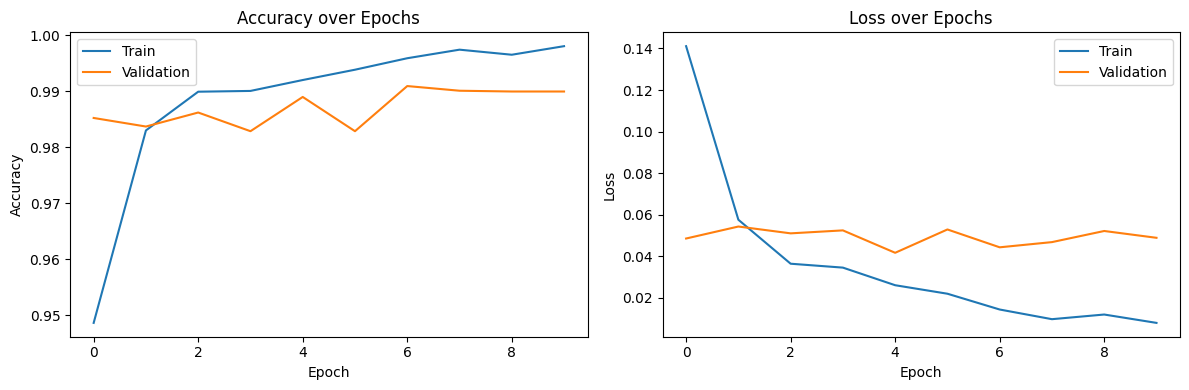

In [8]:
# 画训练过程曲线：accuracy 和 loss 随 epoch 的变化
# Plot training curves: accuracy and loss over epochs
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy 曲线 / Accuracy curve
axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss 曲线 / Loss curve
axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/lstm_training_curves.png', dpi=150)
plt.show()

训练曲线显示模型在每个 epoch 的学习进度。理想情况下训练集和验证集的 accuracy 应该同步上升、loss 同步下降。如果训练 accuracy 远高于验证 accuracy，说明模型过拟合（memorising training data）。

The training curves show learning progress across epochs. Ideally, both train and validation accuracy should rise together. A large gap between them would indicate overfitting.